In [0]:
%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *
from dolfin import *

In [0]:
%%capture
!pip install git+https://bitbucket.org/fenics-apps/cbc.block.git
from dolfin import *
from block import *
from block.dolfin_util import *
from block.iterative import *
from block.algebraic.petsc import *

# Steady Stokes Problem (block)

We consider the steady Stokes problem with Dirichlet BCs defined in the unit square domain $\Omega := {[0,1]}^2$ by the following set of equations:
$$ 
\begin{cases}
  -\boldsymbol{\Delta} \boldsymbol{u} + \boldsymbol{\nabla} p = 0, 
  \qquad&\text{in }\Omega, \\
  \boldsymbol{\nabla} \cdot \boldsymbol{u} = 0, 
  \qquad &\text{in }\Omega, \\
  \boldsymbol{u} = 1\boldsymbol{i} + 0\boldsymbol{j}, \qquad&\text{on }\Gamma^{\text{up}} = \{ 0 \le x \le 1, \, y=1 \}, \\
  \boldsymbol{u} = \boldsymbol{0}, \qquad&\text{on }\partial\Omega \backslash \Gamma^{\text{up}}.
\end{cases}
$$

The algebraic formulation of the finite element approximation has the following block structure
$$
\begin{bmatrix} A & B^T \\ B & 0\end{bmatrix}
\begin{bmatrix}\boldsymbol{U} \\ \boldsymbol{P}\end{bmatrix}
=
\begin{bmatrix}\boldsymbol{f} \\ \boldsymbol{0}\end{bmatrix}.
$$

The preconditioner that must be used is:
$$
            P = \begin{bmatrix}A & 0 \\ 0 & M_p\end{bmatrix},
        $$
where $M_p$ is the mass matrix for the pressure unknown.  


In [0]:
def stokes_block(n):
  mesh = UnitSquareMesh(n, n, 'crossed')

  V = VectorFunctionSpace(mesh, 'CG', 2)
  Q = FunctionSpace(mesh, 'CG', 1)

  def top(x, on_boundary):
    return on_boundary and near(x[1], 1)
  def other(x, on_boundary):
    return on_boundary and not near(x[1], 1)

  bc1 = DirichletBC(V, Constant((1, 0)), top)
  bc2 = DirichletBC(V, Constant((0, 0)), other)
  bc = [bc1, bc2]

  u = TrialFunction(V)
  p = TrialFunction(Q)
  v= TestFunction(V)
  q = TestFunction(Q)

  a = inner(grad(u), grad(v))*dx
  bT = -p*div(v)*dx
  b = -q*div(u)*dx # - in order to mantain symmetry

  f = Constant((0, 0))
  L = dot(f, v)*dx 

  A, LL = assemble_system(a, L)
  B = assemble(b)
  BT = assemble(bT)

  for bci in bc:
    bci.apply(A, LL)
    bci.zero(BT)

  M = block_mat([[A, BT], [B, 0]])
  ff = block_vec([LL, 0])

  # Preconditioner
  AP = AMG(A)
  Mp = InvDiag(assemble(p*q*dx)) # espression of pressure mass matrix
  P = block_mat([[AP, 0], [0, Mp]])

  Minv = ConjGrad(M, precond=P, tolerance=1e-5, maxiter=200)
  u, p = Minv*ff
  return mesh, u, p, V, Q

10
ConjGrad converged [iter=54, time=0.06s, res=9.4e-06]
20
ConjGrad converged [iter=37, time=0.13s, res=9.8e-06]
40
ConjGrad converged [iter=51, time=1.00s, res=9.2e-06]
80
ConjGrad converged [iter=37, time=3.20s, res=9.6e-06]
160
ConjGrad converged [iter=148, time=45.94s, res=7.3e-06]


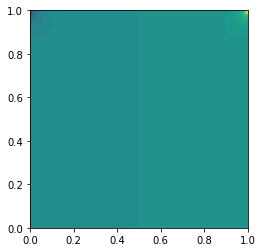

In [0]:
for n in [10, 20, 40, 80, 160]:
  print(n)
  mesh, u, p, V, Q = stokes_block(n)
  plt1 = plot(Function(V, u))
  plt2 = plot(Function(Q, p))

# Stokes Problem with Neumann BC

---



We consider the steady Stokes problem with mixed BCs defined in the unit square domain $\Omega := {[0,1]}^2$ by the following set of equations:
$$ 
\begin{cases}
  -\boldsymbol{\Delta} \boldsymbol{u} + \boldsymbol{\nabla} p = 0, 
  \qquad&\text{in }\Omega, \\
  \boldsymbol{\nabla} \cdot \boldsymbol{u} = 0, 
  \qquad &\text{in }\Omega, \\
\boldsymbol{u} = 1\boldsymbol{i} + 0\boldsymbol{j}, \qquad&\text{on }\Gamma^{\text{right}} = \{ x = 1, \, 0\le y\le1 \}, \\
  (\boldsymbol{\nabla}\boldsymbol{u}-p)\cdot\boldsymbol{n} = \boldsymbol{0}, \qquad&\text{on }\Gamma^{\text{left}} = \{ x = 0, \, 0\le y\le1 \},\\
    \boldsymbol{u} = \boldsymbol{0}, \qquad& \text{on } \partial\Omega\setminus(\Gamma^{\text{right}}\cup\Gamma^{\text{left}}).
\end{cases}
$$

## Classic Fenics approach

In [0]:
def stokes_fenics_Neumann(n):
  mesh = UnitSquareMesh(n, n, 'crossed')
  b_m = MeshFunction('size_t', mesh, mesh.geometric_dimension()-1, 0)
    
  V = VectorElement('CG', mesh.ufl_cell(), 2)
  Q = FiniteElement('CG', mesh.ufl_cell(), 1)
  X = FunctionSpace(mesh, V*Q)

  class topBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 1)

  class bottomBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 0)

  class rightBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[0], 1)

  class leftBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[0], 0)

  top = topBC()
  top.mark(b_m, 1)
  bottom = bottomBC()
  bottom.mark(b_m, 2)
  right = rightBC()
  right.mark(b_m, 3)
  left = leftBC()
  left.mark(b_m, 4)

  bc1 = DirichletBC(X.sub(0), Constant((1, 0)), b_m, 3)
  bc2 = DirichletBC(X.sub(0), Constant((0, 0)), b_m, 1)
  bc3 = DirichletBC(X.sub(0), Constant((0, 0)), b_m, 2)
  bc = [bc1, bc2, bc3]

  ds = Measure('ds', domain=mesh, subdomain_data=b_m)

  u, p = TrialFunctions(X)
  v, q= TestFunctions(X)

  a = inner(grad(u), grad(v))*dx - p*div(v)*dx -q*div(u)*dx
  gN = Constant((0, 0))
  f = Constant((0, 0))
  L = dot(f, v)*dx + dot(v, gN)*ds(4)

  x = Function(X)
  solve(a == L, x, bcs=bc)

  u, p = x.split()
  return mesh, u, p

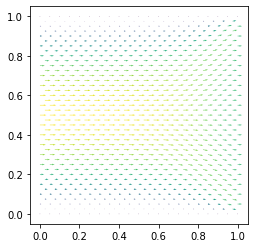

In [0]:
n=20
mesh, u, p = stokes_fenics_Neumann(n)
plot(u)

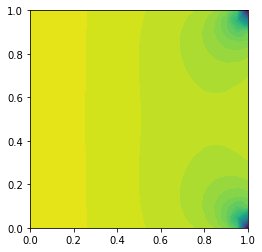

In [0]:
plot(p)

## Block

In [0]:
def stokes_block_Neumann(n, tol, nmax):
  mesh = UnitSquareMesh(n, n, 'crossed')
  b_m = MeshFunction('size_t', mesh, mesh.geometric_dimension()-1, 0)

  V = VectorFunctionSpace(mesh, 'CG', 2)
  Q = FunctionSpace(mesh, 'CG', 1)


  class topBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 1)
  
  class bottomBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 0)
  
  class rightBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[0], 1)

  class leftBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[0], 0)

  top = topBC()
  top.mark(b_m, 1)
  bottom = bottomBC()
  bottom.mark(b_m, 2)
  right = rightBC()
  right.mark(b_m, 3)
  left = leftBC()
  left.mark(b_m, 4)

  bc1 = DirichletBC(V, Constant((1, 0)), b_m, 3)
  bc2 = DirichletBC(V, Constant((0, 0)), b_m, 1)
  bc3 = DirichletBC(V, Constant((0, 0)), b_m, 2)
  bc = [bc1, bc2, bc3]

  ds = Measure('ds', domain=mesh, subdomain_data=b_m)

  u = TrialFunction(V)
  p = TrialFunction(Q)
  v= TestFunction(V)
  q = TestFunction(Q)

  a = inner(grad(u), grad(v))*dx
  bT = -p*div(v)*dx
  b = -q*div(u)*dx # - in order to mantain symmetry
  gN = Constant((0, 0))
  f = Constant((0, 0))
  L = dot(f, v)*dx + dot(v, gN)*ds(4)

  A, LL = assemble_system(a, L)
  B = assemble(b)
  BT = assemble(bT)

  for bci in bc:
    bci.apply(A, LL)
    bci.zero(BT)

  M = block_mat([[A, BT], [B, 0]])
  ff = block_vec([LL, 0])

  # Preconditioner
  AP = AMG(A)
  Mp = assemble(p*q*dx) # espression of pressure mass matrix
  P = block_mat([[AP, 0], [0, Mp]])

  Minv = ConjGrad(M, precond=P, tolerance=tol, maxiter=nmax)
  u, p = Minv*ff
  return mesh, u, p, V, Q

ConjGrad NOT CONV. [iter=1200, time=36.53s, res=1.1e-07]


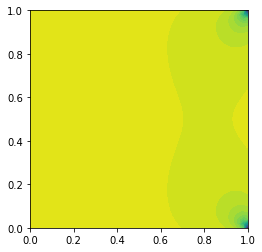

In [0]:
mesh, u, p, V, Q = stokes_block_Neumann(50, 1e-8, 1200)
plot(Function(Q, p))

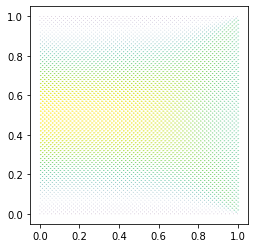

In [0]:
plot(Function(V, u))

## Multiphenics package


In [0]:
%%capture
!pip install git+https://github.com/mathLab/multiphenics.git
from multiphenics import *
from numpy import isclose
import matplotlib.pyplot as plt

In [0]:
def stokes_multifenics_Neumann(n):
  mesh = UnitSquareMesh(n, n, 'crossed')
  b_m = MeshFunction('size_t', mesh, mesh.geometric_dimension()-1, 0)
    
  V = VectorFunctionSpace(mesh, 'CG', 2)
  Q = FunctionSpace(mesh, 'CG', 1)
  X = BlockFunctionSpace([V, Q])

  class topBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 1)

  class bottomBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 0)

  class rightBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[0], 1)

  class leftBC(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[0], 0)

  top = topBC()
  top.mark(b_m, 1)
  bottom = bottomBC()
  bottom.mark(b_m, 2)
  right = rightBC()
  right.mark(b_m, 3)
  left = leftBC()
  left.mark(b_m, 4)

  bc1 = DirichletBC(X.sub(0), Constant((1, 0)), b_m, 3)
  bc2 = DirichletBC(X.sub(0), Constant((0, 0)), b_m, 1)
  bc3 = DirichletBC(X.sub(0), Constant((0, 0)), b_m, 2)
  bc = [bc1, bc2, bc3]
  bcs = BlockDirichletBC([bc, []])

  ds = Measure('ds', domain=mesh, subdomain_data=b_m)

  up = BlockTrialFunction(X)
  vq = BlockTestFunction(X)
  (u, p) = block_split(up)
  (v, q) = block_split(vq)

  a = [[inner(grad(u), grad(v))*dx, - p*div(v)*dx],
       [-q*div(u)*dx, 0]]
  A = block_assemble(a)
  gN = Constant((0, 0))
  f = Constant((0, 0))
  L = [dot(f, v)*dx, dot(v, gN)*ds(4)]
  b = block_assemble(L)
  bcs.apply(A)
  bcs.apply(b)

  UP = BlockFunction(X)
  block_solve(A, UP.block_vector(), b)
  U, P = UP
  return mesh, U, P

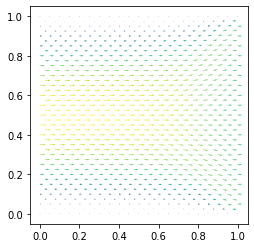

In [0]:
n=20
mesh, u, p = stokes_multifenics_Neumann(n)
plot(u)

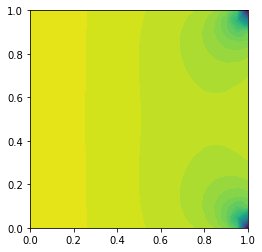

In [0]:
plot(p)

## Scipy
(da non fare, "outside the scope of our course)

# Navier-Stokes problem with Newton linearization

$$
\begin{cases}
  ({\boldsymbol{u}}\cdot\boldsymbol{\nabla})\ \boldsymbol{u}
  -\dfrac{1}{\text{Re}}\boldsymbol{\Delta} \boldsymbol{u} + \boldsymbol{\nabla} p = 0, 
  \qquad&\text{in }\Omega, \\
  \boldsymbol{\nabla} \cdot \boldsymbol{u} = 0, 
  \qquad &\text{in }\Omega, \\
  \boldsymbol{u} = 1\boldsymbol{i} + 0\boldsymbol{j}, \qquad&\text{on }\Gamma^{\text{up}} = \{ 0 \le x \le 1, \, y=1 \}, \\
  \boldsymbol{u} = \boldsymbol{0}, \qquad&\text{on }\partial\Omega \backslash \Gamma^{\text{up}}.
\end{cases}
$$

The linearized problem for the Netwon's method is given by
$$
  a(\boldsymbol{u}_k,\boldsymbol{v}) 
  + c(\boldsymbol{u}_k,\boldsymbol{u}_{k-1},\boldsymbol{v})
  + c(\boldsymbol{u}_{k-1},\boldsymbol{u}_k,\boldsymbol{v}) 
  - b(\boldsymbol{v},p_k) + b(\boldsymbol{u}_k,q)
  =
c(\boldsymbol{u}_{k-1},\boldsymbol{u}_{k-1},\boldsymbol{v}),
$$
where
$$
  a(\boldsymbol{u},\boldsymbol{v}):= \frac{1}{\text{Re}}
  \int_\Omega\boldsymbol{\nabla}{\boldsymbol{u}}:\boldsymbol{\nabla}{\boldsymbol{v}}\, d\boldsymbol{x},\qquad
  b(\boldsymbol{u},p) := -\int_\Omega \boldsymbol{\nabla}\cdot{\boldsymbol{u}}\ p \,d\boldsymbol{x},\qquad
c(\boldsymbol{u},\boldsymbol{v},\boldsymbol{w}) := \int_\Omega (\boldsymbol{u}\cdot\boldsymbol{\nabla})\boldsymbol{v}\ \boldsymbol{w} \, d\vec{x}.
$$

## Simple Method

In [0]:
def implicitNS(n, Re, f, u_top, u_bottom, u_left, u_right):
  advection = None
  mesh = UnitSquareMesh(n, n, 'crossed')

  V = VectorElement('CG', mesh.ufl_cell(), 2)
  Q = FiniteElement('CG', mesh.ufl_cell(), 1)
  X = FunctionSpace (mesh, V*Q)

  # Boundary Conditions
  def top(x, on_boundary):
    return near(x[1], 1)
  def left(x, on_boundary):
    return near(x[0], 0)
  def right(x, on_boundary):
    return near(x[0], 1) 
  def bottom(x, on_boundary):
    return near(x[1], 0)
  def origin(x, on_boundary):
    return near(x[1], 0) and near(x[0], 0)

  bc1 = DirichletBC(X.sub(0), u_top, top)
  bc2 = DirichletBC(X.sub(0), u_bottom, bottom)
  bc3 = DirichletBC(X.sub(0), u_left, left)
  bc4 = DirichletBC(X.sub(0), u_right, right)
  bc5 = DirichletBC(X.sub(1), Constant(0), origin, 'pointwise')

  bc=[bc1, bc2, bc3, bc4, bc5]

  # Weak formulation assembly

  def solveSys(advection, f, bc, X, Re):
    u, p= TrialFunctions(X)
    v, q= TestFunctions(X)
    a = (inner(grad(u), grad(v))/Re - div(v)*p + div(u)*q)*dx
    l = dot(f, v)*dx

    if advection:
      a += (dot(grad(u)*advection, v) + dot(grad(advection)*u, v))*dx
      l += (dot(grad(advection)*advection, v))*dx

    x = Function(X)
    solve(a==l, x, bc)
    u, p = x.split()
    return u, p

  u, p = solveSys(None, f, bc, X, Re)

  it = 0
  itMax = 200
  tol = 1e-8
  res = tol + 1
  print('Inner Newton Method')
  while res > tol and it < itMax:
    u_old = u
    p_old = p
    it += 1
    u, p = solveSys(u_old, f, bc, X, Re)
    res = errornorm(u, u_old, 'H1')/norm(u, 'H1')+errornorm(p, p_old, 'L2')/norm(p, 'L2')
    print('it' + str(it) + ': res=' + str(res))
  
  return u, p

In [9]:
n=15
u_top = Constant((1, 0))
u_bottom = Constant((0, 0))
u_left =Constant((0, 0))
u_right = Constant((0, 0))
f = Constant((0, 0))
Re = 100
u, p = implicitNS(n, Re, f, u_top, u_bottom, u_left, u_right)

Inner Newton Method
it1: res=0.7674966135293602
it2: res=0.11275481172159708
it3: res=0.0014469086080498388
it4: res=3.211869720116849e-07
it5: res=3.196287836204896e-14


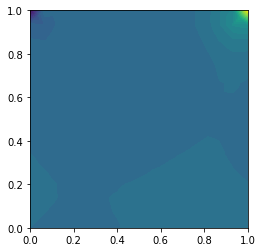

In [10]:
plot(p)

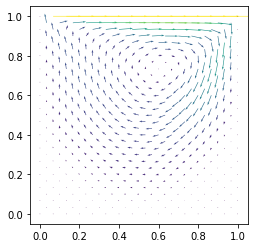

In [0]:
plot(u)

## Stabilized Method

If the pair of spaces $\mathbb{P}^1/\mathbb{P}^1$ is considered, then the linearized problem with the stabilized terms is given by
\begin{multline*}
  a(\boldsymbol{u}_k,\boldsymbol{v}) 
  + c(\boldsymbol{u}_k,\boldsymbol{u}_{k-1},\boldsymbol{v})
  + c(\boldsymbol{u}_{k-1},\boldsymbol{u}_k,\boldsymbol{v}) 
  + b(\boldsymbol{v},p_k) - b(\boldsymbol{u}_k,q) + \\
  \sum_{K\in\mathcal{T}_h} \delta_K \left[{\left(
    (\boldsymbol{u}_k\cdot\boldsymbol{\nabla})
    \boldsymbol{u}_{k-1}
    +(\boldsymbol{u}_{k-1}\cdot\boldsymbol{\nabla})
    \boldsymbol{u}_{k}
    + \boldsymbol{\nabla}{p},
    (\boldsymbol{v}\cdot\boldsymbol{\nabla})
    \boldsymbol{u}_{k-1}
    +(\boldsymbol{u}_{k-1}\cdot\boldsymbol{\nabla})
    \boldsymbol{v}
    + \boldsymbol{\nabla}{q}\right)}_K
    + (\boldsymbol{\nabla}\cdot{\boldsymbol{u}_k}, 
    \boldsymbol{\nabla}\cdot{\boldsymbol{v}})_K\right]= \\ 
c(\boldsymbol{u}_{k-1},\boldsymbol{u}_{k-1},\boldsymbol{v})
+ \sum_{K\in\mathcal{T}_h} \delta_K {\left(
  (\boldsymbol{u}_{k-1}\cdot\boldsymbol{\nabla})
  \boldsymbol{u}_{k-1},
  (\boldsymbol{v}\cdot\boldsymbol{\nabla})
  \boldsymbol{u}_{k-1}
  +(\boldsymbol{u}_{k-1}\cdot\boldsymbol{\nabla})
  \boldsymbol{v}
  + \boldsymbol{\nabla}{q}\right)}_K,
\end{multline*}
where ${(\cdot, \cdot)}_K$ denotes the $L^2$ inner product over the element $K$. The stabilization parameters are defined by
$$
\delta_K = 
\delta \min{\left\{ \frac{h_K}{2 ||\boldsymbol{u}||}_K, \frac{h^2_K \text{Re}}{24} \right\}},\qquad \delta > 0.
$$

In [0]:
def implicitNS_stabilized(n, Re, f, u_top, u_bottom, u_left, u_right):
  advection = None
  mesh = UnitSquareMesh(n, n, 'crossed')

  V = VectorElement('CG', mesh.ufl_cell(), 2)
  Q = FiniteElement('CG', mesh.ufl_cell(), 1)
  X = FunctionSpace (mesh, V*Q)

  # Boundary Conditions
  def top(x, on_boundary):
    return near(x[1], 1)
  def left(x, on_boundary):
    return near(x[0], 0)
  def right(x, on_boundary):
    return near(x[0], 1) 
  def bottom(x, on_boundary):
    return near(x[1], 0)
  def origin(x, on_boundary):
    return near(x[1], 0) and near(x[0], 0)

  bc1 = DirichletBC(X.sub(0), u_top, top)
  bc2 = DirichletBC(X.sub(0), u_bottom, bottom)
  bc3 = DirichletBC(X.sub(0), u_left, left)
  bc4 = DirichletBC(X.sub(0), u_right, right)
  bc5 = DirichletBC(X.sub(1), Constant(0), origin, 'pointwise')

  bc=[bc1, bc2, bc3, bc4, bc5]

  # Weak formulation assembly

  def solveSys(advection, f, bc, X, Re):
    u, p= TrialFunctions(X)
    v, q= TestFunctions(X)
    a = (inner(grad(u), grad(v))/Re - div(v)*p + div(u)*q)*dx
    l = dot(f, v)*dx

    if advection:
      a += (dot(grad(u)*advection, v) + dot(grad(advection)*u, v))*dx
      l += (dot(grad(advection)*advection, v))*dx

      h = CellDiameter(mesh)
      norm = sqrt(dot(advection,advection))
      delta = conditional(1/norm < h*Re/12, h/(2*norm), h**2*Re/24)

      a += delta*(dot(grad(u)*advection + grad(advection)*u + grad(p), 
                     #grad(v)*advection + grad(advection)*v + grad(q))+
                     #dot(div(u), div(v)))*dx
      l += delta*(dot(grad(advection)*advection, 
                     #grad(v)*advection + grad(advection)*v + grad(q)))*dx

    x = Function(X)
    solve(a==l, x, bc)
    u, p = x.split()
    return u, p

  u, p = solveSys(None, f, bc, X, Re)

  it = 0
  itMax = 50
  tol = 1e-6
  res = tol + 1
  print('Inner Newton Method')
  while res > tol and it < itMax:
    u_old = u
    p_old = p
    it += 1
    u, p = solveSys(u_old, f, bc, X, Re)
    res = errornorm(u, u_old, 'H1')/norm(u, 'H1')+errornorm(p, p_old, 'L2')/norm(p, 'L2')
    print('it' + str(it) + ': res=' + str(res))
  
  return u, p

In [0]:
n=15
u_top = Constant((1, 0))
u_bottom = Constant((0, 0))
u_left =Constant((0, 0))
u_right = Constant((0, 0))
f = Constant((0, 0))
Re = 100
u, p = implicitNS_stabilized(n, Re, f, u_top, u_bottom, u_left, u_right)

Inner Newton Method
it1: res=1.0263913056393932
it2: res=0.1341979152569402
it3: res=0.0026788152042337286
it4: res=6.340267013386944e-05
it5: res=3.432719926431281e-06
it6: res=1.6916178103124394e-07


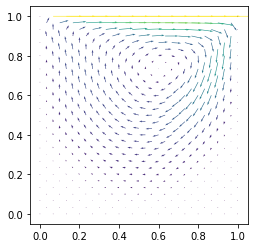

In [0]:
plot(u)

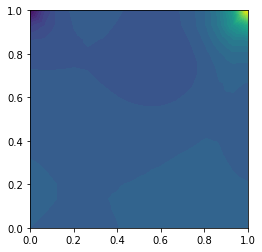

In [0]:
plot(p)